<a href="https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/extras/exercises/01_pytorch_workflow_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01. PyTorch Workflow Exercise Template

The following is a template for the PyTorch workflow exercises.

It's only starter code and it's your job to fill in the blanks.

Because of the flexibility of PyTorch, there may be more than one way to answer the question.

Don't worry about trying to be *right* just try writing code that suffices the question.

You can see one form of [solutions on GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions) (but try the exercises below yourself first!).

In [2]:
# Import necessary libraries
import torch
from torch import nn
import matplotlib.pyplot as plt
from pathlib import Path
print('torch version:', torch.__version__)

torch version: 2.8.0+cu126


In [3]:
# Setup device-agnostic code
if torch.cuda.is_available():
    device = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print('Using device:', device)

Using device: cuda


## 1. Create a straight line dataset using the linear regression formula (`weight * X + bias`).
  * Set `weight=0.3` and `bias=0.9` there should be at least 100 datapoints total.
  * Split the data into 80% training, 20% testing.
  * Plot the training and testing data so it becomes visual.

Your output of the below cell should look something like:
```
Number of X samples: 100
Number of y samples: 100
First 10 X & y samples:
X: tensor([0.0000, 0.0100, 0.0200, 0.0300, 0.0400, 0.0500, 0.0600, 0.0700, 0.0800,
        0.0900])
y: tensor([0.9000, 0.9030, 0.9060, 0.9090, 0.9120, 0.9150, 0.9180, 0.9210, 0.9240,
        0.9270])
```

Of course the numbers in `X` and `y` may be different but ideally they're created using the linear regression formula.

In [4]:
# Create the data parameters
# We'll create a simple linear relationship: y = 2x + 1 with some samples
X = torch.arange(0, 1.0, 0.01).unsqueeze(1)  # shape (100,1)
y = 2 * X + 1

# Split into train and test (80/20)
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size].to(device), X[train_size:].to(device)
y_train, y_test = y[:train_size].to(device), y[train_size:].to(device)

print(f"Number of X samples: {len(X)}")
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Number of X samples: 100
Train size: 80, Test size: 20


In [5]:
# 1. Create a model class (a simple linear regression model)
class LinearModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(in_features=1, out_features=1)
    def forward(self, x):
        return self.linear(x)

In [6]:
# 2. Create an instance of the model, loss function and optimizer
model = LinearModel().to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

## 2. Build a PyTorch model by subclassing `nn.Module`.
  * Inside should be a randomly initialized `nn.Parameter()` with `requires_grad=True`, one for `weights` and one for `bias`.
  * Implement the `forward()` method to compute the linear regression function you used to create the dataset in 1.
  * Once you've constructed the model, make an instance of it and check its `state_dict()`.
  * **Note:** If you'd like to use `nn.Linear()` instead of `nn.Parameter()` you can.

In [7]:
# Training loop (simple)
epochs = 200
history = {'train_loss': []}

for epoch in range(epochs):
    model.train()
    y_pred = model(X_train)
    loss = loss_fn(y_pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    history['train_loss'].append(loss.item())
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs}, loss: {loss.item():.4f}")

Epoch 50/200, loss: 0.0565
Epoch 100/200, loss: 0.0225
Epoch 150/200, loss: 0.0090
Epoch 200/200, loss: 0.0036


In [8]:
# 3. Evaluate on test set
model.eval()
with torch.inference_mode():
    preds = model(X_test)
    test_loss = loss_fn(preds, y_test)
print('Test loss:', test_loss.item())

Test loss: 0.015301713719964027


## 3. Create a loss function and optimizer using `nn.L1Loss()` and `torch.optim.SGD(params, lr)` respectively.
  * Set the learning rate of the optimizer to be 0.01 and the parameters to optimize should be the model parameters from the model you created in 2.
  * Write a training loop to perform the appropriate training steps for 300 epochs.
  * The training loop should test the model on the test dataset every 20 epochs.

In [9]:
# 4. Make predictions with the model
model.eval()
with torch.inference_mode():
    train_preds = model(X_train).cpu()
    test_preds = model(X_test).cpu()

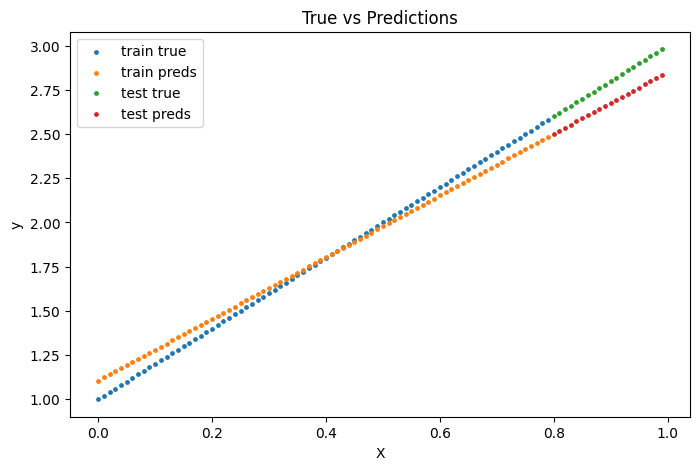

In [10]:
# 4b. Plot the predictions (these may need to be on a specific device)
plt.figure(figsize=(8,5))
plt.scatter(X_train.cpu(), y_train.cpu(), label='train true', s=6)
plt.scatter(X_train.cpu(), train_preds, label='train preds', s=6)
plt.scatter(X_test.cpu(), y_test.cpu(), label='test true', s=6)
plt.scatter(X_test.cpu(), test_preds, label='test preds', s=6)
plt.legend()
plt.xlabel('X')
plt.ylabel('y')
plt.title('True vs Predictions')
plt.show()

## 4. Make predictions with the trained model on the test data.
  * Visualize these predictions against the original training and testing data (**note:** you may need to make sure the predictions are *not* on the GPU if you want to use non-CUDA-enabled libraries such as matplotlib to plot).

In [11]:
# 5. Save your trained model's `state_dict()` to file.
model_dir = Path('/mnt/data/model_exports')
model_dir.mkdir(parents=True, exist_ok=True)
model_path = model_dir / 'simple_linear_state_dict.pth'

# 3. Save the model state dict
torch.save(model.state_dict(), model_path)
print('Saved state_dict to:', model_path)

Saved state_dict to: /mnt/data/model_exports/simple_linear_state_dict.pth


In [12]:
# Create new instance of model and load saved state dict (make sure to put it on the target device)
loaded_model = LinearModel().to(device)
loaded_model.load_state_dict(torch.load(model_path, map_location=device))
loaded_model.eval()
print('Loaded model parameters:')
for name, param in loaded_model.named_parameters():
    print(name, param.data)

Loaded model parameters:
linear.weight tensor([[1.7447]], device='cuda:0')
linear.bias tensor([1.1057], device='cuda:0')


## 5. Save your trained model's `state_dict()` to file.
  * Create a new instance of your model class you made in 2. and load in the `state_dict()` you just saved to it.
  * Perform predictions on your test data with the loaded model and confirm they match the original model predictions from 4.

In [13]:
# Make predictions with loaded model and compare them to the previous
with torch.inference_mode():
    loaded_preds = loaded_model(X_test).cpu()

# Compare
diff = torch.abs(loaded_preds - test_preds)
print('Max difference between original and loaded model predictions:', diff.max().item())

Max difference between original and loaded model predictions: 0.0


In [14]:
# (Optional) Save the entire model (state dict already saved above)
torch.save(model, model_dir / 'simple_linear_model_full.pth')

In [15]:
# (Optional) Load entire model and test
full_loaded = torch.load(model_dir / 'simple_linear_model_full.pth', map_location=device)
with torch.inference_mode():
    full_preds = full_loaded(X_test).cpu()
print('Max diff (full model):', torch.max(torch.abs(full_preds - test_preds)).item())

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL __main__.LinearModel was not an allowed global by default. Please use `torch.serialization.add_safe_globals([__main__.LinearModel])` or the `torch.serialization.safe_globals([__main__.LinearModel])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn more about types accepted b